# Series temporales: componentes, estacionariedad y validación temporal

> Qué cambia cuando los datos tienen un orden en el tiempo: cómo separar tendencia y estacionalidad, qué significa (y cómo se consigue) que una serie sea estacionaria, por qué la validación cruzada habitual engaña y cómo plantear un modelo de predicción con retardos frente a unas líneas base.
>
> **Requisitos previos:** [Flujo de ML y evaluación](01-flujo-ml-y-evaluacion.ipynb) · [Árboles de decisión](08-arboles-decision.ipynb) · **Relacionado:** [Bagging y Random Forest](10-bagging-y-random-forest.ipynb) · [Análisis exploratorio](../03-preparacion-datos/01-analisis-exploratorio.ipynb)

## 1. Idea clave

En una serie temporal las observaciones no son independientes: lo que ocurre este mes depende de lo que ocurrió los anteriores (tendencia, ciclos, estacionalidad). Eso invalida dos supuestos del aprendizaje automático habitual: que se puede **barajar** los datos y que las relaciones aprendidas seguirán valiendo con valores nuevos. Las técnicas de series temporales sirven para **predecir el futuro** (demanda, consumo, tráfico) respetando el orden, y para entender la estructura de la serie (¿crece?, ¿tiene ciclos?).

El flujo habitual es: (1) mirar la serie y descomponerla, (2) transformarla hasta que sea estacionaria, (3) fijar unas **líneas base** sencillas, (4) construir un modelo (estadístico o de aprendizaje automático con retardos) y (5) validarlo **hacia delante en el tiempo**. Este notebook recorre ese flujo con una serie clásica y muestra los errores que más se cometen: validar con particiones aleatorias y esperar que un árbol extrapole una tendencia.

## 2. Conceptos importantes

### 2.1. Qué cambia respecto a los datos tabulares

- **Hay dependencia temporal**: observaciones cercanas se parecen. Una partición aleatoria deja en entrenamiento vecinos inmediatos de los ejemplos de test, y el modelo "ve el futuro".
- **Hay un orden que respetar**: se entrena con el pasado y se evalúa con lo posterior.
- **Interesa extrapolar**: se predicen valores que pueden quedar fuera del rango visto (una tendencia que sigue creciendo). Los modelos basados en árboles, que predicen promedios de ejemplos de entrenamiento, **no pueden** salirse de ese rango (véase [árboles](08-arboles-decision.ipynb)).

### 2.2. Componentes de una serie

Se suele ver una serie $y_t$ como la combinación de:

- **Tendencia** $T_t$: nivel a largo plazo (crecimiento sostenido, declive).
- **Estacionalidad** $S_t$: patrón que se repite con período fijo $m$ (12 meses, 7 días…).
- **Residuo** $R_t$: lo que queda (ruido y efectos no explicados).

El modelo **aditivo** supone $y_t=T_t+S_t+R_t$ (la amplitud de la estacionalidad no cambia con el nivel). El **multiplicativo**, $y_t=T_t\cdot S_t\cdot R_t$ (la amplitud crece con el nivel), se convierte en aditivo tomando logaritmos: $\log y_t=\log T_t+\log S_t+\log R_t$. En la **descomposición clásica**: la tendencia es una media móvil centrada de orden $m$; se resta a la serie; la estacionalidad es el promedio de lo que queda para cada posición del ciclo (cada mes); y el residuo es el resto. Es descriptiva, no un modelo predictivo: la media centrada usa valores futuros.

### 2.3. Estacionariedad

Una serie es **(débilmente) estacionaria** si su media y su varianza son constantes y la covarianza entre $y_t$ e $y_{t-k}$ depende solo del retardo $k$, no del instante $t$. Importa porque casi todos los modelos aprenden relaciones que suponen que se mantendrán en el futuro: con tendencia o varianza creciente, el futuro no se parece al pasado.

Se consigue estacionaridad con transformaciones:

- **Logaritmo**, para estabilizar la varianza si crece con el nivel.
- **Diferencia** regular $\nabla y_t = y_t - y_{t-1}$, que elimina una tendencia, y **diferencia estacional** $\nabla_m y_t = y_t - y_{t-m}$, que elimina la estacionalidad de período $m$. Se pueden combinar: $\nabla\nabla_m y_t$.

La **función de autocorrelación** (ACF) mide la correlación entre la serie y ella misma desplazada $k$ pasos: $\rho_k=\mathrm{Corr}(y_t, y_{t-k})$. En una serie con tendencia decrece muy lentamente (todas las correlaciones son altas); en una con estacionalidad hay picos en los múltiplos de $m$. El contraste de **Dickey–Fuller aumentado** (ADF) tiene como hipótesis nula que la serie **no** es estacionaria (tiene una raíz unitaria): un $p$-valor pequeño (por debajo de 0,05) permite rechazarla. Lo usaremos en 3.3 junto a los gráficos.

### 2.4. Validación temporal y líneas base

La validación debe imitar el uso real: entrenar con el pasado y evaluar con el futuro inmediato. En la **validación hacia delante** (*forward chaining*, `TimeSeriesSplit`) cada partición entrena con todo lo anterior a un bloque de test, y el bloque se va desplazando hacia el final. Se promedia el error de todos los bloques.

Antes de modelar se fijan **líneas base** (*baselines*):

- **Ingenua** (*naive*): la predicción es el último valor observado, $\hat y_{t}=y_{t-1}$.
- **Ingenua estacional**: la predicción es el valor del mismo período del ciclo anterior, $\hat y_t=y_{t-m}$.

Un modelo que no mejore estas líneas no merece la pena. Las métricas habituales son el MAE y el RMSE (en unidades de la serie) y el MAPE (en porcentaje, que falla si hay valores cercanos a cero).

### 2.5. Modelos de predicción

| Familia | Idea | Ejemplos |
|---|---|---|
| **Estadísticos** | Modelan explícitamente tendencia, estacionalidad y dependencia | Suavizado exponencial (ETS, Holt–Winters), ARIMA/SARIMA (autorregresión + diferencias + medias móviles) |
| **Aprendizaje automático con retardos** | Reformulan el problema como aprendizaje supervisado: las variables son retardos, calendario y estadísticos móviles | Regresión lineal, Random Forest, *Gradient Boosting* |
| **Redes** | Aprenden la dependencia temporal con memoria | LSTM, Transformers |

En el segundo enfoque se construye una tabla con una fila por instante: el objetivo es $y_t$ y las variables son $y_{t-1}, y_{t-2},\dots$, $y_{t-m}$ y, quizá, el mes. Hay dos formas de predecir **varios pasos**: **recursiva** (se predice un paso y se usa como retardo del siguiente, acumulando error) o **directa** (un modelo por horizonte). En este notebook predecimos **un paso adelante**, usando como retardos valores reales.

## 3. Código

Usamos la serie clásica de **pasajeros mensuales de una aerolínea** (1949–1960, 144 meses, en miles de pasajeros; en R se conoce como `AirPassengers`) que scikit-learn no incluye pero seaborn sí publica como `flights`, con el formato "largo" (año, mes, pasajeros) y los meses como texto abreviado, por lo que construimos un índice de fechas. Es una serie con tendencia creciente y una estacionalidad anual cuya amplitud **crece** con el nivel (multiplicativa), ideal para ver todos los conceptos del apartado 2 en poco espacio.

Usamos `statsmodels` para el contraste de estacionariedad y un modelo SARIMA, y scikit-learn para un modelo lineal y un bosque con retardos.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

### 3.1. Datos

(144,) 1949-01-01 1960-12-01
1949-01-01    112.0
1949-02-01    118.0
1949-03-01    132.0
Freq: MS


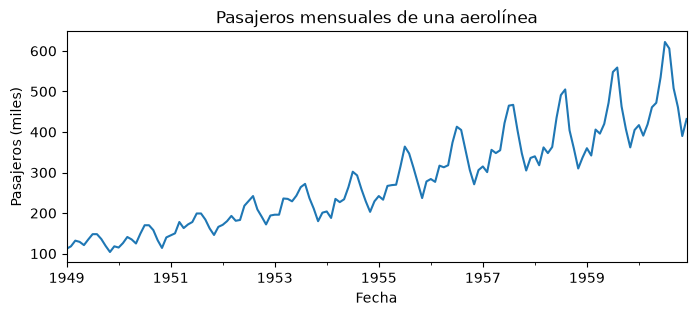

In [2]:
vuelos = sns.load_dataset("flights")
fecha = pd.to_datetime(vuelos["year"].astype(str) + "-" + vuelos["month"].astype(str) + "-01", format="%Y-%b-%d")
serie = pd.Series(vuelos["passengers"].to_numpy(dtype=float), index=fecha, name="pasajeros").asfreq("MS")   # frecuencia mensual explícita
print(serie.shape, serie.index.min().date(), serie.index.max().date())
print(serie.head(3).to_string())

fig, ax = plt.subplots(figsize=(8, 3))
serie.plot(ax=ax)
ax.set_title("Pasajeros mensuales de una aerolínea")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pasajeros (miles)")
plt.show()

La serie crece, repite un patrón anual (picos en verano) y la **amplitud del patrón aumenta con el nivel**: es multiplicativa. Trabajaremos con el logaritmo.

### 3.2. Descomposición

Implementamos la descomposición clásica de 2.2 sobre el logaritmo de la serie (modelo aditivo en logs): media móvil centrada de orden 12 (con dos pasos para centrarla, porque 12 es par), promedio por mes y residuo.

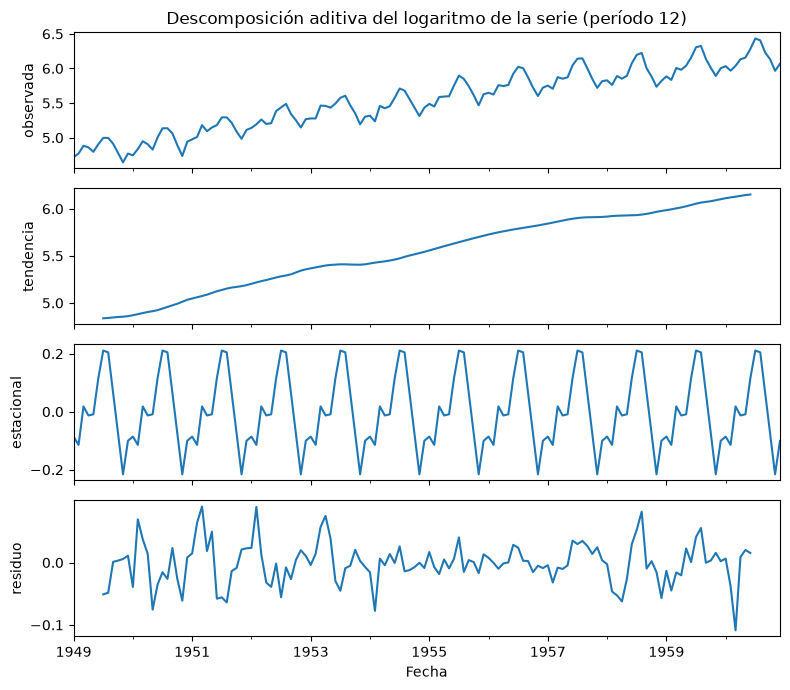

Factor estacional por mes (ene-dic), en la escala original:
1     0.92
2     0.89
3     1.02
4     0.99
5     0.99
6     1.12
7     1.23
8     1.23
9     1.07
10    0.93
11    0.81
12    0.90


In [3]:
serie_log = np.log(serie)

def descomponer(s, periodo=12):
    tendencia = s.rolling(periodo, center=True).mean()
    if periodo % 2 == 0:                       # período par: se promedian dos medias consecutivas para centrar
        tendencia = tendencia.rolling(2).mean().shift(-1)
    sin_tendencia = s - tendencia
    estacional = sin_tendencia.groupby(np.arange(len(s)) % periodo).transform("mean")
    estacional = estacional - estacional.mean()
    return pd.DataFrame({"observada": s, "tendencia": tendencia, "estacional": estacional, "residuo": sin_tendencia - estacional})

comp = descomponer(serie_log)
fig, axes = plt.subplots(4, 1, figsize=(8, 7), sharex=True)
for ax, col in zip(axes, comp.columns):
    comp[col].plot(ax=ax)
    ax.set_ylabel(col)
axes[0].set_title("Descomposición aditiva del logaritmo de la serie (período 12)")
axes[3].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

print("Factor estacional por mes (ene-dic), en la escala original:")
print(np.exp(comp["estacional"].iloc[:12]).round(2).set_axis(range(1, 13)).to_string())

La tendencia crece de forma sostenida y la estacionalidad es estable de un año a otro. Los factores multiplicativos dicen que en julio y agosto el tráfico es un 23 % mayor que la tendencia y en noviembre un 19 % menor. El residuo es pequeño (dentro de ±0,1 en logaritmos) y sin patrón estacional, aunque en 1950–52 y 1958–59 conserva algo de estructura. Qué ocurre si **el período está mal**:

In [4]:
print("Desviación típica del residuo según el período usado:")
print({p: round(descomponer(serie_log, p)["residuo"].std(), 3) for p in [6, 7, 10, 12, 24]})

Desviación típica del residuo según el período usado:
{6: np.float64(0.056), 7: np.float64(0.094), 10: np.float64(0.118), 12: np.float64(0.034), 24: np.float64(0.034)}


Con el período correcto (12) el residuo es mínimo (0,034). Con 24, un **múltiplo** del correcto, el resultado es igual de bueno (0,034); con 6, un divisor, es peor (0,056) porque no separa bien el ciclo anual; con períodos que no encajan (7 o 10) el residuo se multiplica por casi 3 y por más de 3 (0,094 y 0,118): parte de la estacionalidad se queda en él. Conocer el período real es un dato del problema, no algo que se ajusta.

### 3.3. Estacionariedad: diferencias y autocorrelación

Comparamos la dispersión de la serie en logaritmos, tras una diferencia estacional ($\nabla_{12}$) y tras diferencia regular más estacional ($\nabla\nabla_{12}$), y dibujamos la autocorrelación de cada una.

Desviación típica -> log: 0.441 | dif. estacional: 0.062 | dif. regular + estacional: 0.046
log(pasajeros)               autocorrelación en los retardos 1, 12 y 24: [0.97 0.99 0.98]
diferencia estacional        autocorrelación en los retardos 1, 12 y 24: [ 0.72 -0.26 -0.06]
dif. regular + estacional    autocorrelación en los retardos 1, 12 y 24: [-0.34 -0.43 -0.02]


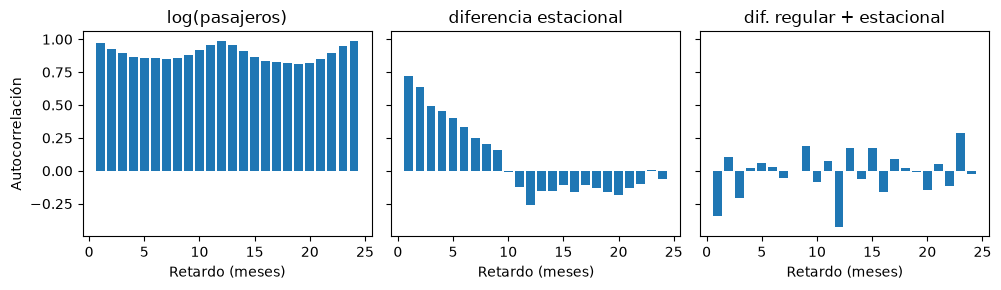

In [5]:
d12 = serie_log.diff(12)               # diferencia estacional
d1_12 = serie_log.diff().diff(12)      # diferencia regular + estacional
print("Desviación típica -> log:", round(serie_log.std(), 3), "| dif. estacional:", round(d12.std(), 3), "| dif. regular + estacional:", round(d1_12.std(), 3))

def acf(s, nlags=24):
    s = s.dropna()
    return np.array([s.autocorr(k) for k in range(1, nlags + 1)])

fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
for ax, (nombre, s) in zip(axes, [("log(pasajeros)", serie_log), ("diferencia estacional", d12), ("dif. regular + estacional", d1_12)]):
    a = acf(s)
    ax.bar(range(1, 25), a)
    ax.set_title(nombre)
    ax.set_xlabel("Retardo (meses)")
    print(f"{nombre:28s} autocorrelación en los retardos 1, 12 y 24:", a[[0, 11, 23]].round(2))
axes[0].set_ylabel("Autocorrelación")
plt.tight_layout()
plt.show()

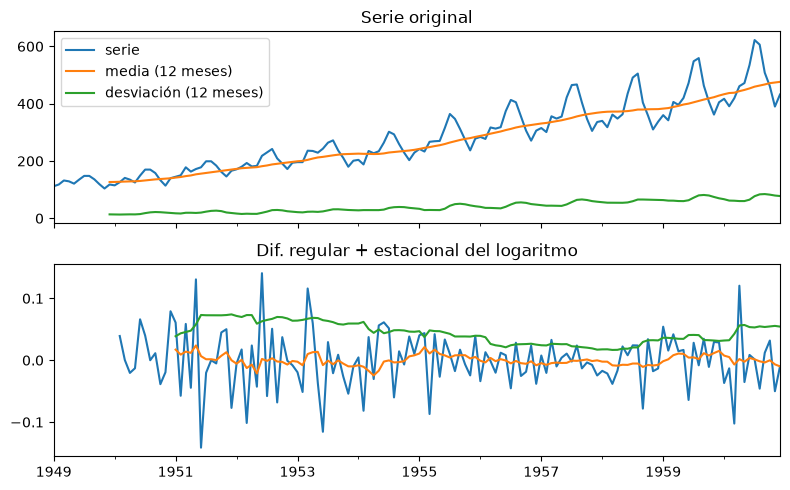

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
for ax, s, titulo in [(axes[0], serie, "Serie original"), (axes[1], d1_12, "Dif. regular + estacional del logaritmo")]:
    s.plot(ax=ax, label="serie")
    s.rolling(12).mean().plot(ax=ax, label="media (12 meses)")
    s.rolling(12).std().plot(ax=ax, label="desviación (12 meses)")
    ax.set_title(titulo)
axes[0].legend()
plt.tight_layout()
plt.show()

In [7]:
for nombre, s in [("log(pasajeros)", serie_log), ("diferencia estacional", d12), ("dif. regular + estacional", d1_12)]:
    adf = adfuller(s.dropna(), autolag="AIC", result_object=True)
    print(f"{nombre:28s} estadístico ADF: {adf.statistic:6.2f}   p-valor: {adf.pvalue:.4f}")

log(pasajeros)               estadístico ADF:  -1.72   p-valor: 0.4224
diferencia estacional        estadístico ADF:  -2.71   p-valor: 0.0724
dif. regular + estacional    estadístico ADF:  -4.44   p-valor: 0.0002


La serie en logaritmos tiene una autocorrelación altísima en todos los retardos (0,97 en el 1, 0,99 en el 12, 0,98 en el 24): es la huella de una tendencia. Con la diferencia estacional baja a 0,72 en el retardo 1 (aún queda tendencia) y a $-0{,}26$ en el 12. Con la diferencia regular **y** estacional desaparece la autocorrelación persistente ($-0{,}02$ en el 24), y la dispersión pasa de 0,441 a 0,062 y a 0,046. En el gráfico inferior, la media móvil oscila alrededor de 0 y la desviación se mantiene entre 0,02 y 0,07, sin la deriva de la serie original, donde las dos crecen con el nivel. Los coeficientes negativos que quedan en los retardos 1 y 12 ($-0{,}34$ y $-0{,}43$) son la firma del conocido "modelo de las aerolíneas" de Box y Jenkins, un SARIMA con medias móviles de orden 1 regular y estacional, que se ajustó a esta misma serie y que probamos en 3.4.

El contraste ADF lo confirma: con el logaritmo no se puede rechazar que la serie sea no estacionaria ($p=0{,}42$); con la diferencia estacional sola queda en el límite ($p=0{,}07$, no se rechaza al 5 %); y con la diferencia regular **y** estacional se rechaza con claridad ($p=0{,}0002$).

### 3.4. Predicción un paso adelante con retardos y validación temporal

Construimos la tabla supervisada de 2.5. Con retardos del logaritmo ($y_{t-1}$, $y_{t-2}$, $y_{t-3}$, $y_{t-12}$) y, alternativamente, con el **crecimiento anual** $c_t=\log y_t-\log y_{t-12}$, que es una serie estacionaria (y sus retardos). Para el segundo enfoque se predice $c_t$ y se reconstruye la serie: $\hat y_t=\exp(\log y_{t-12}+\hat c_t)$. Evaluamos con `TimeSeriesSplit` de 5 particiones de 12 meses (los últimos 60 meses de la serie) y damos el MAE en miles de pasajeros, comparando con las líneas base de 2.4.

In [8]:
marco = pd.DataFrame({"y_log": serie_log})
for k in [1, 2, 3, 12]:
    marco[f"lag{k}"] = serie_log.shift(k)
crec = serie_log - serie_log.shift(12)           # crecimiento anual (estacionario)
marco["crec"] = crec
for k in [1, 2, 3, 12]:
    marco[f"crec{k}"] = crec.shift(k)
marco["mes"] = marco.index.month
marco["t"] = np.arange(len(marco))
marco = marco.dropna()
print(marco.shape, "primera fecha:", marco.index.min().date())

cv = TimeSeriesSplit(n_splits=5, test_size=12)
cols_lag = ["lag1", "lag2", "lag3", "lag12"]
cols_crec = ["crec1", "crec2", "crec3", "crec12"]
nuevo_bosque = lambda: RandomForestRegressor(n_estimators=200, min_samples_leaf=2, random_state=42, n_jobs=-1)

def evaluar(modelo, columnas, objetivo, base=None):
    errores = []
    for i_tr, i_te in cv.split(marco):
        tr, te = marco.iloc[i_tr], marco.iloc[i_te]
        pred = modelo().fit(tr[columnas], tr[objetivo]).predict(te[columnas])
        if base:                                  # se reconstruye el nivel: log(y_{t-12}) + crecimiento
            pred = te[base] + pred
        errores.append(mean_absolute_error(np.exp(te["y_log"]), np.exp(pred)))
    return np.mean(errores), np.std(errores)

def evaluar_sarima():
    # SARIMA(0,1,1)(0,1,1)12 sobre el log: se ajusta con todo el pasado de cada partición y se predice cada mes
    # del bloque de test incorporando los meses reales anteriores (un paso adelante, sin reestimar los parámetros)
    errores = []
    for i_tr, i_te in cv.split(marco):
        fechas_te = marco.index[i_te]
        pasado = serie_log[serie_log.index < fechas_te[0]]
        ajuste = SARIMAX(pasado, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False)
        ampliado = ajuste.append(serie_log[fechas_te], refit=False)
        pred = ampliado.get_prediction(start=fechas_te[0], end=fechas_te[-1]).predicted_mean
        errores.append(mean_absolute_error(serie[fechas_te], np.exp(pred)))
    return np.mean(errores), np.std(errores)

def evaluar_ingenua(columna):
    errores = [mean_absolute_error(np.exp(marco.iloc[i_te]["y_log"]), np.exp(marco.iloc[i_te][columna])) for _, i_te in cv.split(marco)]
    return np.mean(errores), np.std(errores)

resultados = {
    "Ingenua (último mes)": evaluar_ingenua("lag1"),
    "Ingenua estacional (mismo mes del año anterior)": evaluar_ingenua("lag12"),
    "Lineal sobre retardos del log": evaluar(LinearRegression, cols_lag, "y_log"),
    "Random Forest sobre retardos del log": evaluar(nuevo_bosque, cols_lag, "y_log"),
    "Lineal sobre el crecimiento anual": evaluar(LinearRegression, cols_crec, "crec", base="lag12"),
    "Random Forest sobre el crecimiento anual": evaluar(nuevo_bosque, cols_crec, "crec", base="lag12"),
    "SARIMA(0,1,1)(0,1,1)12 sobre el log": evaluar_sarima(),
}
pd.DataFrame(resultados, index=["MAE (miles de pasajeros)", "desviación entre particiones"]).T.round(1)

(120, 12) primera fecha: 1951-01-01


,MAE (miles de pasajeros),desviación entre particiones
Ingenua (último mes),37.6,6.4
Ingenua estacional (mismo mes del año anterior),38.4,13.2
Lineal sobre retardos del log,15.8,4.5
Random Forest sobre retardos del log,30.0,7.3
Lineal sobre el crecimiento anual,10.1,5.3
Random Forest sobre el crecimiento anual,11.2,5.0
"SARIMA(0,1,1)(0,1,1)12 sobre el log",9.5,3.9


- Las dos **líneas base** quedan en torno a 38 (el último mes y el mismo mes del año anterior fallan lo mismo, porque la serie crece cada año).
- El modelo **lineal con retardos** mejora mucho (15,8): captura la tendencia porque extrapola.
- El **Random Forest con los mismos retardos** es el peor modelo de aprendizaje automático (30,0): predice promedios de valores ya vistos y la serie, creciente, sale del rango de entrenamiento. Es el problema de extrapolación de 2.1.
- Si en lugar del nivel se predice el **crecimiento anual** (estacionario), el bosque mejora a 11,2 y la lineal a 10,1. Los dos son más del triple de buenos que la línea base, y la diferencia entre ambos (1,1) es pequeña frente a la dispersión entre particiones (5,0), así que no se puede decir que uno sea mejor.

- El **SARIMA** del modelo de las aerolíneas, con solo dos parámetros (medias móviles regular y estacional) sobre una serie con una diferencia regular y otra estacional, obtiene el MAE más bajo (9,5), pero tampoco se distingue de los modelos con retardos del crecimiento (dispersión de 3,9 a 5,3 entre particiones). Con una sola serie corta, un modelo estadístico clásico bien elegido compite con el aprendizaje automático.

La moraleja es que el modelo no cambió: **cambió el objetivo**. Hacerlo estacionario es lo que permite usar un modelo de árboles. Lo vemos en el último año y medio:

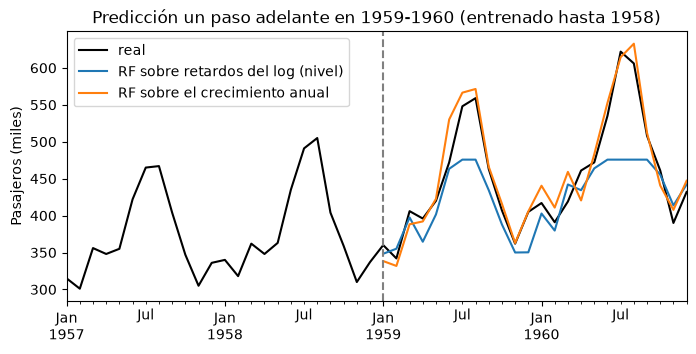

MAE en 1959-1960 -> sobre el nivel: 35.5 | sobre el crecimiento: 16.8


In [9]:
corte = "1959-01-01"
tr, te = marco[marco.index < corte], marco[marco.index >= corte]
pred_nivel = np.exp(nuevo_bosque().fit(tr[cols_lag], tr["y_log"]).predict(te[cols_lag]))
pred_crec = np.exp(te["lag12"] + nuevo_bosque().fit(tr[cols_crec], tr["crec"]).predict(te[cols_crec]))

fig, ax = plt.subplots(figsize=(8, 3.5))
serie[serie.index >= "1957-01-01"].plot(ax=ax, color="k", label="real")
pd.Series(pred_nivel, index=te.index).plot(ax=ax, label="RF sobre retardos del log (nivel)")
pd.Series(pred_crec.to_numpy(), index=te.index).plot(ax=ax, label="RF sobre el crecimiento anual")
ax.axvline(pd.Timestamp(corte), color="gray", ls="--")
ax.set_title("Predicción un paso adelante en 1959-1960 (entrenado hasta 1958)")
ax.set_ylabel("Pasajeros (miles)")
ax.legend()
plt.show()
print("MAE en 1959-1960 -> sobre el nivel:", round(mean_absolute_error(np.exp(te["y_log"]), pred_nivel), 1),
      "| sobre el crecimiento:", round(mean_absolute_error(np.exp(te["y_log"]), pred_crec), 1))

El bosque entrenado sobre el nivel se **queda plano en torno a 475**, sin llegar a los picos de verano de 1959 y 1960 (≈ 560 y ≈ 620), que superan lo visto en el entrenamiento (MAE de 35,5 en 1959–1960); el entrenado sobre el crecimiento sigue la tendencia (16,8).

### 3.5. Por qué no se debe validar con particiones aleatorias

Evaluamos el mismo bosque (retardos, mes e índice temporal) con validación cruzada mezclada y con validación temporal. El MAE está en escala logarítmica (≈ error relativo).

In [10]:
cols_ml = cols_lag + ["mes", "t"]
resultados_cv = {}
for nombre, esquema in [("Validación cruzada mezclada (KFold, shuffle)", KFold(5, shuffle=True, random_state=42)),
                        ("Validación temporal (TimeSeriesSplit)", cv)]:
    puntuaciones = cross_val_score(nuevo_bosque(), marco[cols_ml], marco["y_log"], cv=esquema, scoring="neg_mean_absolute_error")
    resultados_cv[nombre] = -puntuaciones.mean()
pd.Series(resultados_cv, name="MAE (escala logarítmica)").round(3)

Validación cruzada mezclada (KFold, shuffle)    0.053
Validación temporal (TimeSeriesSplit)           0.076
Name: MAE (escala logarítmica), dtype: float64

La validación mezclada da un error de 0,053 (≈ 5 %) y la temporal de 0,076 (≈ 8 %): el primero es **optimista** porque nunca pide al modelo predecir fuera del rango (siempre tiene meses vecinos de entrenamiento a ambos lados) y porque el modelo ve el futuro. Los dos se calculan sobre particiones distintas, así que la cifra exacta de la diferencia no es comparable, pero la dirección sí: la validación aleatoria **subestima el error real** que tendrá el modelo en producción.

## 4. Parámetros importantes y errores comunes

### 4.1. Parámetros principales

| Parámetro / decisión | Qué controla | Consejo |
|---|---|---|
| Período estacional $m$ | Longitud del ciclo (12 meses, 7 días, 24 horas) | Es un dato del problema; un múltiplo del real funciona, un valor cualquiera, no (3.2) |
| Modelo aditivo o multiplicativo | Si la amplitud estacional depende del nivel | Si crece con el nivel, usa logaritmo (modelo multiplicativo) |
| Orden de diferenciación | Cuánta tendencia y estacionalidad se elimina | La mínima que deje la serie estable; dibuja la ACF tras cada paso |
| Retardos usados como variables | Cuánta memoria ve el modelo | Los primeros, y los del período ($t-m$); más retardos no siempre ayudan |
| `TimeSeriesSplit(n_splits, test_size, gap, max_train_size)` | Número de bloques de test, su tamaño, hueco entre train y test y ventana de entrenamiento | `test_size` igual al horizonte real de predicción; `gap` si hay retardos o ventanas que cruzarían la frontera |
| Horizonte | Cuántos pasos adelante se predice | Un paso es más fácil; para más pasos, estrategia recursiva o directa |

### 4.2. Errores comunes

- **Validar con `KFold` mezclado o `train_test_split` aleatorio** (3.5): da un error optimista. Entrena siempre con lo anterior y evalúa con lo posterior.
- **No comparar con las líneas base.** Un modelo con MAE 30 parece razonable hasta que ves que "repetir el mes anterior" da 38 y uno mejor, 10.
- **Esperar que un árbol extrapole una tendencia** (3.4): los árboles y bosques no predicen por encima del máximo de entrenamiento. Predice una magnitud estacionaria (crecimiento, diferencias) o usa un modelo lineal.
- **Usar la descomposición como variable de entrada.** La tendencia de la descomposición clásica usa valores *posteriores* (media centrada) y, calculada con toda la serie, filtra información del futuro al modelo. Úsala solo para explorar.
- **Calcular transformaciones con toda la serie** (medias, escalado, estadísticos móviles centrados) antes de partir. Calcúlalos solo con datos del pasado de cada instante.
- **Sobrediferenciar.** Cada diferencia extra introduce autocorrelación negativa y aumenta la varianza. Con la serie de 3.3, la dispersión baja hasta 0,046 con una diferencia regular y una estacional, y sube a 0,075 si se añade otra diferencia regular y a 0,100 si se añade otra estacional.
- **Ignorar el calendario**: años bisiestos, festivos, número de días hábiles del mes. A menudo explican residuos que parecen ruido.
- **Presentar predicciones un paso adelante como si fueran a un año vista.** Las cifras de 3.4 usan valores reales como retardos; con una predicción recursiva a varios pasos el error es mayor.
- **Mezclar escalas al reconstruir.** Si se modela el logaritmo o una diferencia, el error debe medirse en la escala original, deshaciendo la transformación (`np.exp`) antes de calcular el MAE.

### 4.3. Algunos modelos estadísticos
- **Suavizado exponencial (ETS, Holt–Winters)**: promedia el pasado con pesos que decaen y añade componentes de tendencia y estacionalidad; muy competitivo con series cortas.
- **ARIMA(p, d, q)**: $p$ retardos de la serie (autorregresión), $d$ diferencias y $q$ retardos del error (medias móviles); **SARIMA** añade la parte estacional. Es el modelo con el que se ajusta esta serie en la literatura clásica.

## 5. Comparación con métodos relacionados

| Enfoque | Cuándo funciona bien | Extrapola tendencia | Variables externas | Inconveniente |
|---|---|---|---|---|
| **Líneas base** (ingenua, estacional) | Siempre como referencia | Solo repite | No | Sirven de suelo, no de solución |
| **ETS / Holt–Winters** | Series cortas, una sola serie, tendencia y estacionalidad claras | Sí | No (en la versión básica) | No incorpora fácilmente otras variables |
| **ARIMA / SARIMA** | Una sola serie y dependencia lineal; necesitas intervalos de predicción | Sí, mediante diferencias | Con ARIMAX | Hay que elegir órdenes; una serie por modelo |
| **Regresión lineal con retardos** | Tendencia clara; punto de partida simple | Sí | Sí | Solo relaciones lineales |
| **Random Forest / [boosting](11-boosting.ipynb) con retardos** | Muchas series o variables externas; relaciones no lineales | **No**, salvo que la serie sea estacionaria | Sí | Requiere la ingeniería de variables de 2.5 y la serie estacionaria |
| **Redes (LSTM, Transformers)** | Muchos datos y secuencias largas | Limitada | Sí | Datos, cómputo y ajuste; no suele ganar con una serie corta |

Para muchas series con pocas observaciones (como esta) los modelos estadísticos y la regresión con retardos suelen bastar; el aprendizaje automático compensa cuando hay muchas series, variables explicativas o relaciones no lineales.

## 6. Referencias

### Fuentes

- Box, G. E. P., Jenkins, G. M. y Reinsel, G. C. (1976). *Time Series Analysis: Forecasting and Control* (serie G, pasajeros de una aerolínea). Origen de la serie; versión descargada con seaborn [`load_dataset("flights")`](https://seaborn.pydata.org/generated/seaborn.load_dataset.html) del repositorio [seaborn-data](https://github.com/mwaskom/seaborn-data).
- scikit-learn: [`TimeSeriesSplit`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html), [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html), [`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html), [`cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html).
- statsmodels: [`adfuller`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.adfuller.html), [`SARIMAX`](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html).
- pandas: [*Time series / date functionality*](https://pandas.pydata.org/docs/user_guide/timeseries.html) (`to_datetime`, `rolling`, `shift`, `diff`, `Series.autocorr`).

### Para saber más

- Hyndman, R. J. y Athanasopoulos, G. (2021). [*Forecasting: Principles and Practice*](https://otexts.com/fpp3/) (3.ª ed.). OTexts. Libro libre, el manual más usado: descomposición, ETS, ARIMA y evaluación de predicciones.
- Box, G. E. P., Jenkins, G. M., Reinsel, G. C. y Ljung, G. M. (2016). *Time Series Analysis: Forecasting and Control* (5.ª ed.). Wiley. La referencia clásica de los modelos ARIMA.